In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import OrdinalEncoder

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
zscores_plasmid_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-plasmid.csv")
zscores_control_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-control.csv")

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_10019/1146336700.py:1: DtypeWarning: Columns (7,26,111,112,113,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_plasmid_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-plasmid.csv")
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_10019/1146336700.py:2: DtypeWarning: Columns (7,26,111,112,113,114,115) have mixed types. Specify dtype option on import or set low_memory=False.
  zscores_control_unambiguous_VEPannotated = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-control.csv")


In [70]:
zscores_palsmid_vs_control_EG_annotated = zscores_plasmid_unambiguous_VEPannotated[zscores_plasmid_unambiguous_VEPannotated['Drug']=='DO']
#reset index
zscores_palsmid_vs_control_EG_annotated = zscores_palsmid_vs_control_EG_annotated.reset_index(drop=True)

In [71]:
zscores_palsmid_vs_control_EG_annotated.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Source,CRISPR Enzyme,Edit Window,Target Taxon,Target Assembly,Target Genome Sequence,Target Gene ID,Target Gene Strand,Target Transcript ID,RefSeq match transcript (MANE Select),Target Domain,sgRNA Context Sequence,sgRNA Sequence Start Pos. (global),sgRNA Orientation,Nucleotide Edits (global),Guide Edits,Nucleotide Edits,Amino Acid Edits,Mutation Category,Constraint Violations,Note,hgvs,hgvs ProtVar,Location,Allele,Consequence,IMPACT,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,CANONICAL,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,CCDS,ENSP,SWISSPROT,TREMBL,UNIPARC,UNIPROT_ISOFORM,SIFT_pathogenicity,SIFT_class,PolyPhen_pathogenicity,PolyPhen_class,HGVS_OFFSET,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,VAR_SYNONYMS,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,REVEL,ClinPred,am_class,am_pathogenicity,Enformer_SAD,Enformer_SAR,EVE_CLASS,EVE_SCORE,OpenTargets_geneId,OpenTargets_l2g,Aloft_Confidence,Aloft_Fraction_transcripts_affected,Aloft_pred,Aloft_prob_Dominant,Aloft_prob_Recessive,Aloft_prob_Tolerant,AlphaMissense_pred,AlphaMissense_score,BayesDel_addAF_pred,BayesDel_addAF_score,BayesDel_noAF_pred,BayesDel_noAF_score,DANN_score,DEOGEN2_pred,DEOGEN2_score,ESM1b_pred,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,Ensembl_geneid,Ensembl_proteinid,Ensembl_transcriptid,GERP++_NR,GERP++_RS,LIST-S2_pred,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_pred,MetaLR_score,MetaRNN_pred,MetaRNN_score,MetaSVM_pred,MetaSVM_score,MutFormer_score,MutationAssessor_pred,MutationAssessor_score,MutationTaster_pred,MutationTaster_score,PROVEAN_pred,PROVEAN_score,PrimateAI_pred,Uniprot_acc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,aapos,bStatistic,fathmm-XF_coding_pred,fathmm-XF_coding_score,gMVP_score,genename,phastCons100way_vertebrate,phyloP100way_vertebrate,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,BLOSUM62,LOEUF,mutfunc_exp,mutfunc_int,mutfunc_mod,mutfunc_motif,ada_score,rf_score,AA
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,DO,-0.126512,non-hit,NaN,SpyoCas9NG,4..8,9606,GRCh38,NC_000005.10,ENSG00000164327,-,ENST00000357387.8,NM_152756.5,CDS,TAACAAAAAACATCGTAGTAGCAGTGATCC,38950510,sense,38950523G>A,C_7,3325C>T,His1109Tyr,Missense,NaN,NaN,ENST00000357387.8:c.3325C>T,NM_152756.5:c.3325C>T,5:38950523-38950523,A,missense_variant,MODERATE,Transcript,ENST00000357387.8,protein_coding,31/38,NaN,ENST00000357387.8:c.3325C>T,ENSP00000349959.3:p.His1109Tyr,3347.0,3325.0,1109.0,H/Y,Cat/Tat,rs1413326068,C,C/T,NaN,-1.0,NaN,HGNC,HGNC:28611,YES,MANE_Select,NM_152756.5,NaN,1.0,P4,CCDS34148.1,ENSP00000349959,Q6R327.172,NaN,UPI00003529F3,Q6R327-1,1.0,tolerated_low_confidence,0.000,benign,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000007,0.000024,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214,0.463040,likely_benign,0.0685,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,0.0685,T,-0.114447,T,-0.402171,0.970933,T,0.045001,T,-4.388,5.314964,0.516773,4.111072,0.361058,ENSG00000164327,ENSP00000349959,ENST00000357387,5.75,5.75,D,0.917608,0.44121,0.445060,0.093490,T,0.0689,T,0.179100,T,-1.0259,0.000785,N,0.345,".,.,.,.",".,.,.,.",N,-0.22,T,Q6R327,0.157308,0.157308,

In [ ]:
zscores_plasmid_unambiguous_VEPannotated.head()

# Data Inspection

In [ ]:
print(f'Shape of the annotated dataset: {zscores_plasmid_unambiguous_VEPannotated.shape}')

In [8]:
print(f'Shape of the control vs plasmid (EG) annotated dataset: {zscores_palsmid_vs_control_EG_annotated.shape}')

Shape of the control vs plasmid (EG) annotated dataset: (28086, 198)


## Mutation Categories

In [9]:
# Table for Ensembl VEP  mutation categories
VEP_mutation_category = (
    zscores_palsmid_vs_control_EG_annotated['Consequence']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Count'})
)
VEP_mutation_category['Percentage'] = (VEP_mutation_category['Count'] / VEP_mutation_category['Count'].sum() * 100).round(1)

#Table for Beagle mutation categories
Beagle_mutation_category = (
    zscores_palsmid_vs_control_EG_annotated['Mutation Category']
    .value_counts()
    .reset_index()
    .rename(columns={'count': 'Count'})
)
Beagle_mutation_category['Percentage'] = (Beagle_mutation_category['Count'] / Beagle_mutation_category['Count'].sum() * 100).round(1)

In [ ]:
VEP_mutation_category

In [ ]:
Beagle_mutation_category

In [ ]:
# Ensembl VEP Category Pie Chart

# Ensure numeric type
VEP_mutation_category['Percentage'] = pd.to_numeric(VEP_mutation_category['Percentage'])
VEP_mutation_category['Count'] = pd.to_numeric(VEP_mutation_category['Count'])

# Group categories with <2% into 'Others'
mask_small = VEP_mutation_category['Percentage'] < 2
if mask_small.any():
    others_row = pd.DataFrame({
        'Consequence': ['Others'],
        'Count': [VEP_mutation_category.loc[mask_small, 'Count'].sum()],
        'Percentage': [VEP_mutation_category.loc[mask_small, 'Percentage'].sum()]
    })
    vep_plot_df = pd.concat([VEP_mutation_category.loc[~mask_small], others_row], ignore_index=True)

# Sort by percentage (desc)
vep_plot_df = vep_plot_df.sort_values(by='Percentage', ascending=False)

# Legend labels: "name (xx.x%)"
vep_labels = [f"{row['Consequence']} ({row['Percentage']:.1f}%)"
              for _, row in vep_plot_df.iterrows()]

fig, ax = plt.subplots(figsize=(4,4))
wedges = ax.pie(vep_plot_df['Percentage'], startangle=90)[0]

ax.legend(
    wedges, vep_labels,
    title="Ensembl VEP Mutation Categories",
    title_fontsize=6,
    fontsize=5,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.tight_layout()
plt.show()

In [ ]:
# Beagle Mutation Category Pie Chart
beagle_plot_df = Beagle_mutation_category.copy()

beagle_plot_df['Percentage'] = pd.to_numeric(beagle_plot_df['Percentage'])
beagle_plot_df['Count'] = pd.to_numeric(beagle_plot_df['Count'])

# thr=0 -> No grouping, thr>0 -> Group small categories into 'Others'
thr = 0
if thr and thr > 0:
    mask_small = beagle_plot_df['Percentage'] < thr
    if mask_small.any():
        others_row = pd.DataFrame({
            'Mutation Category': ['Others'],
            'Count': [beagle_plot_df.loc[mask_small, 'Count'].sum()],
            'Percentage': [beagle_plot_df.loc[mask_small, 'Percentage'].sum()],
        })
        beagle_plot_df = pd.concat([beagle_plot_df.loc[~mask_small], others_row], ignore_index=True)

# Sort by percentage (desc)
beagle_plot_df = beagle_plot_df.sort_values(by='Percentage', ascending=False)

# Build legend labels
beagle_labels = [f"{row['Mutation Category']} ({row['Percentage']:.1f}%)"
                 for _, row in beagle_plot_df.iterrows()]

# Plot
fig, ax = plt.subplots(figsize=(4, 4))
wedges = ax.pie(beagle_plot_df['Percentage'], startangle=90)[0]

ax.legend(
    wedges, 
    beagle_labels,
    title="Beagle Mutation Categories", title_fontsize=6, fontsize=5,
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.tight_layout()
plt.show()

In [ ]:
# Cross-tab between VEP and Beagle categories
crosstab = pd.crosstab(zscores_plasmid_unambiguous_VEPannotated['Consequence'], zscores_plasmid_unambiguous_VEPannotated['Mutation Category'])

# Show table
print(crosstab)

In [13]:
VEP_info = pd.DataFrame({
    'dtype': zscores_palsmid_vs_control_EG_annotated.dtypes,
    'non-null count': zscores_palsmid_vs_control_EG_annotated.notna().sum(),
    'missing (%)': zscores_palsmid_vs_control_EG_annotated.isna().mean() * 100,
    'n_unique': zscores_palsmid_vs_control_EG_annotated.nunique(),
    'example': zscores_palsmid_vs_control_EG_annotated.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(zscores_palsmid_vs_control_EG_annotated)} rows and {len(zscores_palsmid_vs_control_EG_annotated.columns)} columns')
VEP_info

28086 rows and 198 columns


,dtype,non-null count,missing (%),n_unique,example
Guide,object,28086,0.000000,14043,"[AAAAAACATCGTAGTAGCAG, AAAAAACTCAACAGCAGTGA, A..."
CADD_PHRED,float64,28086,0.000000,3016,"[20.4, 23.4, 25.4]"
hgvs,object,28086,0.000000,10490,"[ENST00000357387.8:c.3325C>T, ENST00000369535...."
hgvs ProtVar,object,28086,0.000000,10490,"[NM_152756.5:c.3325C>T, NM_002524.5:c.511C>T, ..."
Location,object,28086,0.000000,10490,"[5:38950523-38950523, 1:114708594-114708594, 3..."
Allele,object,28086,0.000000,2,"[A, T]"
Consequence,object,28086,0.000000,15,"[missense_variant, synonymous_variant, splice_..."
IMPACT,object,28086,0.000000,4,"[MODERATE, LOW, HIGH]"
Feature_type,object,28086,0.000000,1,[Transcript]
Feature,object,28086,0.000000,30,"[ENST00000357387.8, ENST00000369535.5, ENST000..."


In [ ]:
VEP_info = pd.DataFrame({
    'dtype': zscores_control_unambiguous_VEPannotated.dtypes,
    'non-null count': zscores_control_unambiguous_VEPannotated.notna().sum(),
    'missing (%)': zscores_control_unambiguous_VEPannotated.isna().mean() * 100,
    'n_unique': zscores_control_unambiguous_VEPannotated.nunique(),
    'example': zscores_control_unambiguous_VEPannotated.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(zscores_control_unambiguous_VEPannotated)} rows and {len(zscores_control_unambiguous_VEPannotated.columns)} columns')
VEP_info

## Checking Alpha Missense Agreement between Ensembl and dbSNP

In [278]:
df_amscore = zscores_palsmid_vs_control_EG_annotated.dropna(subset=["am_pathogenicity",  "AlphaMissense_score"])
r = df_amscore["am_pathogenicity"].corr(df_amscore[ "AlphaMissense_score"])
n= len(df_amscore)

In [ ]:
# Scatter plot with Pearson correlation
fig, ax = plt.subplots(figsize=(4,4))

ax.scatter(
    df_amscore["am_pathogenicity"],
    df_amscore["AlphaMissense_score"],
    s=8, alpha=0.6
)

lims = [
    min(df_amscore["am_pathogenicity"].min(), df_amscore["AlphaMissense_score"].min()),
    max(df_amscore["am_pathogenicity"].max(), df_amscore["AlphaMissense_score"].max())
]

ax.plot(lims, lims, "--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("AlphaMissense Ensembl VEP score", fontsize=6)
ax.set_ylabel("AlphaMissense dbSNP score", fontsize=6)


ax.text(1.02, 0.5, f"n = {n}\nPearson r = {r:.4f}",
        transform=ax.transAxes, va="center", fontsize=7)

plt.tight_layout()
plt.show()

## Missigness Analysis

#### Heatmap

In [ ]:
plt.figure(figsize=(30, 10))

sns.heatmap(
    zscores_palsmid_vs_control_EG_annotated.isnull(),
    cbar=False,
    cmap='binary_r'
)

#plt.title("Missing Values Heatmap", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Samples", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks([])  # Hide sample indices
plt.tight_layout()
plt.show()

#### Missingness Histogram

In [ ]:

# Calculate percentage of missing values per column
missing_percent = zscores_palsmid_vs_control_EG_annotated.isna().mean() * 100

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(missing_percent, bins=20, edgecolor="black", alpha=0.7)

plt.xlabel("Missing values per feature (%)", fontsize=6)
plt.ylabel("Number of features", fontsize=6)


plt.tight_layout()
plt.show()

# Also print the features sorted by missingness
#missing_percent.sort_values(ascending=False)

#### Analyze feature's missing data per mutation category

In [10]:
missing_perc = zscores_palsmid_vs_control_EG_annotated.isna().mean() * 100  

# Select features in the 40–60% cluster
cluster_feats = missing_perc[(missing_perc >= 40) & (missing_perc <= 60)].index.tolist()
print("Features in 40–60% missingness cluster:\n", cluster_feats)

# Check missingness distribution of these features across mutation categories
for feat in cluster_feats:
    print(f"\n=== {feat} (overall missing: {missing_perc[feat]:.2f}%) ===")
    summary = (
        zscores_palsmid_vs_control_EG_annotated.groupby("Mutation Category")[feat]
          .apply(lambda x: x.isna().mean() * 100)
          .sort_values(ascending=False)
    )
    print(summary)

Features in 40–60% missingness cluster:
 ['SIFT_pathogenicity', 'SIFT_class', 'PolyPhen_pathogenicity', 'PolyPhen_class', 'PHENO', 'VAR_SYNONYMS', 'REVEL', 'ClinPred', 'am_class', 'am_pathogenicity', 'AlphaMissense_pred', 'AlphaMissense_score', 'BayesDel_addAF_pred', 'BayesDel_addAF_score', 'BayesDel_noAF_pred', 'BayesDel_noAF_score', 'DANN_score', 'DEOGEN2_pred', 'DEOGEN2_score', 'ESM1b_pred', 'ESM1b_score', 'Eigen-PC-phred_coding', 'Eigen-PC-raw_coding', 'Eigen-phred_coding', 'Eigen-raw_coding', 'Ensembl_geneid', 'Ensembl_proteinid', 'Ensembl_transcriptid', 'GERP++_NR', 'GERP++_RS', 'LIST-S2_pred', 'LIST-S2_score', 'MPC_rankscore', 'MVP_score', 'MetaLR_pred', 'MetaLR_score', 'MetaRNN_pred', 'MetaRNN_score', 'MetaSVM_pred', 'MetaSVM_score', 'MutFormer_score', 'MutationAssessor_pred', 'MutationAssessor_score', 'MutationTaster_pred', 'MutationTaster_score', 'PROVEAN_pred', 'PROVEAN_score', 'PrimateAI_pred', 'Uniprot_acc', 'VARITY_ER_LOO_score', 'VARITY_ER_score', 'VARITY_R_LOO_score', '

In [11]:
missing_perc = zscores_palsmid_vs_control_EG_annotated.isna().mean() * 100  

# Select features in the cluster
cluster_feats = missing_perc[(missing_perc >= 60) & (missing_perc <= 80)].index.tolist()
print("Features in 60–80% missingness cluster:\n", cluster_feats)

# Check missingness distribution of these features across mutation categories
for feat in cluster_feats:
    print(f"\n=== {feat} (overall missing: {missing_perc[feat]:.2f}%) ===")
    summary = (
        zscores_palsmid_vs_control_EG_annotated.groupby("Mutation Category")[feat]
          .apply(lambda x: x.isna().mean() * 100)
          .sort_values(ascending=False)
    )
    print(summary)

Features in 60–80% missingness cluster:
 ['TREMBL', 'gnomADe_AF', 'gnomADe_AFR_AF', 'gnomADe_AMR_AF', 'gnomADe_ASJ_AF', 'gnomADe_EAS_AF', 'gnomADe_FIN_AF', 'gnomADe_MID_AF', 'gnomADe_NFE_AF', 'gnomADe_REMAINING_AF', 'gnomADe_SAS_AF', 'SOMATIC', 'EVE_CLASS', 'EVE_SCORE', 'MPC_score', 'gMVP_score', 'mutfunc_exp', 'mutfunc_mod']

=== TREMBL (overall missing: 67.75%) ===
Mutation Category
Missense           71.749784
Splice-donor       69.863014
Nonsense           68.079470
Silent             63.400320
Splice-acceptor    62.867647
Intron             62.264151
UTR                57.812500
Name: TREMBL, dtype: float64

=== gnomADe_AF (overall missing: 66.77%) ===
Mutation Category
Splice-acceptor    94.852941
Nonsense           77.350993
Splice-donor       75.342466
Missense           67.382531
Silent             63.738218
Intron             57.861635
UTR                56.250000
Name: gnomADe_AF, dtype: float64

=== gnomADe_AFR_AF (overall missing: 66.77%) ===
Mutation Category
Splice-accep

In [12]:
missing_perc = zscores_palsmid_vs_control_EG_annotated.isna().mean() * 100  

# Select features in the 80–100% cluster
cluster_feats = missing_perc[(missing_perc >= 80) & (missing_perc <= 100)].index.tolist()
print("Features in 80–100% missingness cluster:\n", cluster_feats)

# Check missingness distribution of these features across mutation categories
for feat in cluster_feats:
    print(f"\n=== {feat} (overall missing: {missing_perc[feat]:.2f}%) ===")
    summary = (
        zscores_palsmid_vs_control_EG_annotated.groupby("Mutation Category")[feat]
          .apply(lambda x: x.isna().mean() * 100)
          .sort_values(ascending=False)
    )
    print(summary)

Features in 80–100% missingness cluster:
 ['Source', 'Constraint Violations', 'Note', 'INTRON', 'DISTANCE', 'FLAGS', 'MANE_PLUS_CLINICAL', 'HGVS_OFFSET', 'AF', 'gnomADg_AF', 'gnomADg_AFR_AF', 'gnomADg_AMI_AF', 'gnomADg_AMR_AF', 'gnomADg_ASJ_AF', 'gnomADg_EAS_AF', 'gnomADg_FIN_AF', 'gnomADg_MID_AF', 'gnomADg_NFE_AF', 'gnomADg_REMAINING_AF', 'gnomADg_SAS_AF', 'CLIN_SIG', 'PUBMED', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'TRANSCRIPTION_FACTORS', 'Enformer_SAD', 'Enformer_SAR', 'OpenTargets_geneId', 'OpenTargets_l2g', 'Aloft_Confidence', 'Aloft_Fraction_transcripts_affected', 'Aloft_pred', 'Aloft_prob_Dominant', 'Aloft_prob_Recessive', 'Aloft_prob_Tolerant', 'MaveDB_nt', 'MaveDB_pro', 'MaveDB_score', 'MaveDB_urn', 'MaxEntScan_alt', 'MaxEntScan_diff', 'MaxEntScan_ref', 'mutfunc_int', 'mutfunc_motif', 'ada_score', 'rf_score']

=== Source (overall missing: 100.00%) ===
Mutation Category
Intron             100.0
Missense           100.0
Nonsense           100.0
Silent 

# Drop genomAD_ features

In [14]:
#Check which columns will be dropped
cols_gnomAD_all = [c for c in zscores_palsmid_vs_control_EG_annotated.columns
                   if c.startswith('gnomADe_') or c.startswith('gnomADg_')]
print(f"{len(cols_gnomAD_all)} gnomAD columns to drop")
cols_gnomAD_all

21 gnomAD columns to drop


['gnomADe_AF',
 'gnomADe_AFR_AF',
 'gnomADe_AMR_AF',
 'gnomADe_ASJ_AF',
 'gnomADe_EAS_AF',
 'gnomADe_FIN_AF',
 'gnomADe_MID_AF',
 'gnomADe_NFE_AF',
 'gnomADe_REMAINING_AF',
 'gnomADe_SAS_AF',
 'gnomADg_AF',
 'gnomADg_AFR_AF',
 'gnomADg_AMI_AF',
 'gnomADg_AMR_AF',
 'gnomADg_ASJ_AF',
 'gnomADg_EAS_AF',
 'gnomADg_FIN_AF',
 'gnomADg_MID_AF',
 'gnomADg_NFE_AF',
 'gnomADg_REMAINING_AF',
 'gnomADg_SAS_AF']

In [72]:
# Drop gnomAD columns
zscores_palsmid_vs_control_EG_annotated_processed = zscores_palsmid_vs_control_EG_annotated.drop(columns=cols_gnomAD_all)

In [185]:
# Drop gnomAD columns for control
zscores_control_unambiguous_VEPannotated_processed = zscores_control_unambiguous_VEPannotated.drop(columns=cols_gnomAD_all)

In [20]:
#Check missing values again
VEP_info_processed = pd.DataFrame({
    'dtype': zscores_palsmid_vs_control_EG_annotated_processed.dtypes,
    'non-null count': zscores_palsmid_vs_control_EG_annotated_processed.notna().sum(),
    'missing (%)': zscores_palsmid_vs_control_EG_annotated_processed.isna().mean() * 100,
    'n_unique': zscores_palsmid_vs_control_EG_annotated_processed.nunique(),
    'example': zscores_palsmid_vs_control_EG_annotated_processed.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(zscores_palsmid_vs_control_EG_annotated_processed)} rows and {len(zscores_palsmid_vs_control_EG_annotated_processed.columns)} columns')
VEP_info_processed

28086 rows and 177 columns


,dtype,non-null count,missing (%),n_unique,example
Guide,object,28086,0.000000,14043,"[AAAAAACATCGTAGTAGCAG, AAAAAACTCAACAGCAGTGA, A..."
CADD_PHRED,float64,28086,0.000000,3016,"[20.4, 23.4, 25.4]"
hgvs,object,28086,0.000000,10490,"[ENST00000357387.8:c.3325C>T, ENST00000369535...."
hgvs ProtVar,object,28086,0.000000,10490,"[NM_152756.5:c.3325C>T, NM_002524.5:c.511C>T, ..."
Location,object,28086,0.000000,10490,"[5:38950523-38950523, 1:114708594-114708594, 3..."
Allele,object,28086,0.000000,2,"[A, T]"
Consequence,object,28086,0.000000,15,"[missense_variant, synonymous_variant, splice_..."
IMPACT,object,28086,0.000000,4,"[MODERATE, LOW, HIGH]"
Feature_type,object,28086,0.000000,1,[Transcript]
Feature,object,28086,0.000000,30,"[ENST00000357387.8, ENST00000369535.5, ENST000..."


In [ ]:
# Calculate percentage of missing values per column
missing_percent = zscores_plasmid_unambiguous_VEPannotated_processed.isna().mean() * 100

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(missing_percent, bins=20, edgecolor="black", alpha=0.7)

plt.xlabel("Missing values per feature (%)", fontsize=6)
plt.ylabel("Number of features", fontsize=6)

# Example threshold line at 30%
#plt.axvline(30, color="red", linestyle="--", label="30% threshold")
#plt.legend()

plt.tight_layout()
plt.show()

# Drop features with >75% of missing data

In [21]:
def drop_missing_features(df, threshold=75, keep_columns=None):
    """
    Drops columns from df with missingness > threshold,
    except those listed in keep_cols.
    """
    if keep_columns is None:
        keep_columns = []
    
    missing_data_percentage = df.isna().mean() * 100
    cols_to_drop = [
        col for col in missing_data_percentage.index
        if (missing_data_percentage[col] > threshold) and (col not in keep_columns)
    ]
    return df.drop(columns=cols_to_drop), cols_to_drop

In [73]:
# Features to keep even if above threshold (splice-related)
features_to_keep = [
    "Source",
    "rf_score",
    "ada_score",
    "MaxEntScan_ref",
    "MaxEntScan_alt",
    "MaxEntScan_diff"
]

# Drop features with more than 75% missing values, except features to keep 
zscores_palsmid_vs_control_EG_annotated_processed, dropped_features = drop_missing_features(zscores_palsmid_vs_control_EG_annotated_processed, threshold=75, keep_columns=features_to_keep)

In [186]:
# Drop features with more than 75% missing values, except features to keep for control
zscores_control_unambiguous_VEPannotated_processed, dropped_features_control = drop_missing_features(zscores_control_unambiguous_VEPannotated_processed, threshold=75, keep_columns=features_to_keep)

In [74]:
print(f"Dropped {len(dropped_features)} features with >75% missing values (except splice-related):")
print(dropped_features)
print(f"Remaining features: {len(zscores_palsmid_vs_control_EG_annotated_processed.columns)}")

Dropped 32 features with >75% missing values (except splice-related):
['Constraint Violations', 'Note', 'INTRON', 'DISTANCE', 'FLAGS', 'MANE_PLUS_CLINICAL', 'HGVS_OFFSET', 'AF', 'CLIN_SIG', 'PUBMED', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE', 'TRANSCRIPTION_FACTORS', 'Enformer_SAD', 'Enformer_SAR', 'OpenTargets_geneId', 'OpenTargets_l2g', 'Aloft_Confidence', 'Aloft_Fraction_transcripts_affected', 'Aloft_pred', 'Aloft_prob_Dominant', 'Aloft_prob_Recessive', 'Aloft_prob_Tolerant', 'MaveDB_nt', 'MaveDB_pro', 'MaveDB_score', 'MaveDB_urn', 'mutfunc_int', 'mutfunc_mod', 'mutfunc_motif']
Remaining features: 145


# Drop other columns not useful for classification

In [9]:
cols_to_drop = [
    # Identifiers
    'hgvs', 'hgvs ProtVar', 'Location', 'Allele', 'Feature_type', 'UNIPARC', 'SWISSPROT', 'ENSP', 'CCDS', 'MANE_SELECT', 'MANE', 'CANONICAL',
    'REF_ALLELE', 'UPLOADED_ALLELE', 'STRAND', 'HGVSc', 'SYMBOL_SOURCE', 'Nucleotide Edits', 'Target Taxon', 'Target Assembly',	'Target Gene ID',
    'Target Gene Strand', 'Target Domain', 'Nucleotide Edits (global)', 'Guide Edits', 'Target Genome Sequence', 'HGNC_ID', 'AA', 'EXON', 
    'cDNA_position', 'HGVSp', 'CDS_position', 'Codons', 'Amino_acids', 'Protein_position', 'Existing_variation', 'UNIPROT_ISOFORM', 'aapos',
    'Uniprot_acc', 'Ensembl_transcriptid', 'Ensembl_proteinid', 'genename', 'Ensembl_geneid', 'SpliceAI_pred_SYMBOL', 'VAR_SYNONYMS', 'TREMBL',
    'MaveDB_urn', 'MaveDB_pro', 'MaveDB_nt', 'INTRON', 'PUBMED', 'Aloft_Fraction_transcripts_affected', 'Constraint Violations', 
    'OpenTargets_geneId', 'Feature', 'APPRIS', 

    #Categorical label of scores
    'BayesDel_noAF_pred', 'BayesDel_addAF_pred', 'MutationTaster_pred', 'fathmm-XF_coding_pred', 'SIFT_class', 'MetaLR_pred', 'MetaSVM_pred',
    'MetaRNN_pred', 'AlphaMissense_pred', 'ESM1b_pred', 'PolyPhen_class', 'am_class', 'MutationAssessor_pred', 'DEOGEN2_pred', 'LIST-S2_pred',
    'PROVEAN_pred', 'EVE_CLASS',

    #Experimental data
    'CRISPR Enzyme', 'Edit Window', 'sgRNA Context Sequence', 'sgRNA Sequence Start Pos. (global)', 'sgRNA Orientation',

    #Other
    'PHENO', 'SOMATIC', 'MutationTaster_score', 'BIOTYPE',

    # Drop mutation category from Ensembl VEP annotations (we keep Beagle's)
    'Consequence'
]


meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits', 
    'Source', 'Hit_class'
]

#don't forget to take the zscores from the training set

In [78]:
#Drop the columns to drop 
zscores_palsmid_vs_control_EG_annotated_processed = zscores_palsmid_vs_control_EG_annotated_processed.drop(columns=cols_to_drop, errors='ignore')
#Print the shape of the processed dataset
print(f'Shape of the processed dataset: {zscores_palsmid_vs_control_EG_annotated_processed.shape}')

Shape of the processed dataset: (28086, 69)


In [77]:
#Drop only for the plasmid vs control for EG - 'Source' column
zscores_palsmid_vs_control_EG_annotated_processed = zscores_palsmid_vs_control_EG_annotated_processed.drop(columns=['Source'], errors='ignore')

In [ ]:
#Drop the columns to drop for control
zscores_control_unambiguous_VEPannotated_processed = zscores_control_unambiguous_VEPannotated_processed.drop(columns=cols_to_drop, errors="ignore")
#Print the shape of the processed dataset for control
print(f'Shape of the processed control dataset: {zscores_control_unambiguous_VEPannotated_processed.shape}')

In [ ]:
#Print number of columns dropped
print(f'Total number of columns dropped: {len(zscores_plasmid_unambiguous_VEPannotated.columns) - len(zscores_plasmid_unambiguous_VEPannotated_processed.columns)}')
#Print the shape of the processed dataset
print(f'Shape of the processed dataset: {zscores_plasmid_unambiguous_VEPannotated_processed.shape}')

In [35]:
#Check missing values again
VEP_info_processed = pd.DataFrame({
    'dtype': zscores_palsmid_vs_control_EG_annotated_processed.dtypes,
    'non-null count': zscores_palsmid_vs_control_EG_annotated_processed.notna().sum(),
    'missing (%)': zscores_palsmid_vs_control_EG_annotated_processed.isna().mean() * 100,
    'n_unique': zscores_palsmid_vs_control_EG_annotated_processed.nunique(),
    'example': zscores_palsmid_vs_control_EG_annotated_processed.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(zscores_palsmid_vs_control_EG_annotated_processed)} rows and {len(zscores_palsmid_vs_control_EG_annotated_processed.columns)} columns')
VEP_info_processed

28086 rows and 68 columns


,dtype,non-null count,missing (%),n_unique,example
Guide,object,28086,0.000000,14043,"[AAAAAACATCGTAGTAGCAG, AAAAAACTCAACAGCAGTGA, A..."
CADD_PHRED,float64,28086,0.000000,3016,"[20.4, 23.4, 25.4]"
LOEUF,float64,28086,0.000000,30,"[0.305, 0.55, 0.319]"
CADD_RAW,float64,28086,0.000000,10474,"[2.813513, 3.741037, 4.475384]"
Mutation Category,object,28086,0.000000,7,"[Missense, Silent, Splice-acceptor]"
Amino Acid Edits,object,28086,0.000000,8729,"[His1109Tyr, Leu171Phe, Thr930Ile]"
RefSeq match transcript (MANE Select),object,28086,0.000000,30,"[NM_152756.5, NM_002524.5, NM_006219.3]"
IMPACT,object,28086,0.000000,4,"[MODERATE, LOW, HIGH]"
Hit_class,object,28086,0.000000,3,"[non-hit, negative, positive]"
zscore,float64,28086,0.000000,27465,"[-0.1265120188067817, 0.4918440305585236, 0.16..."


In [ ]:
zscores_plasmid_unambiguous_VEPannotated_processed['Mutation Category'].value_counts()

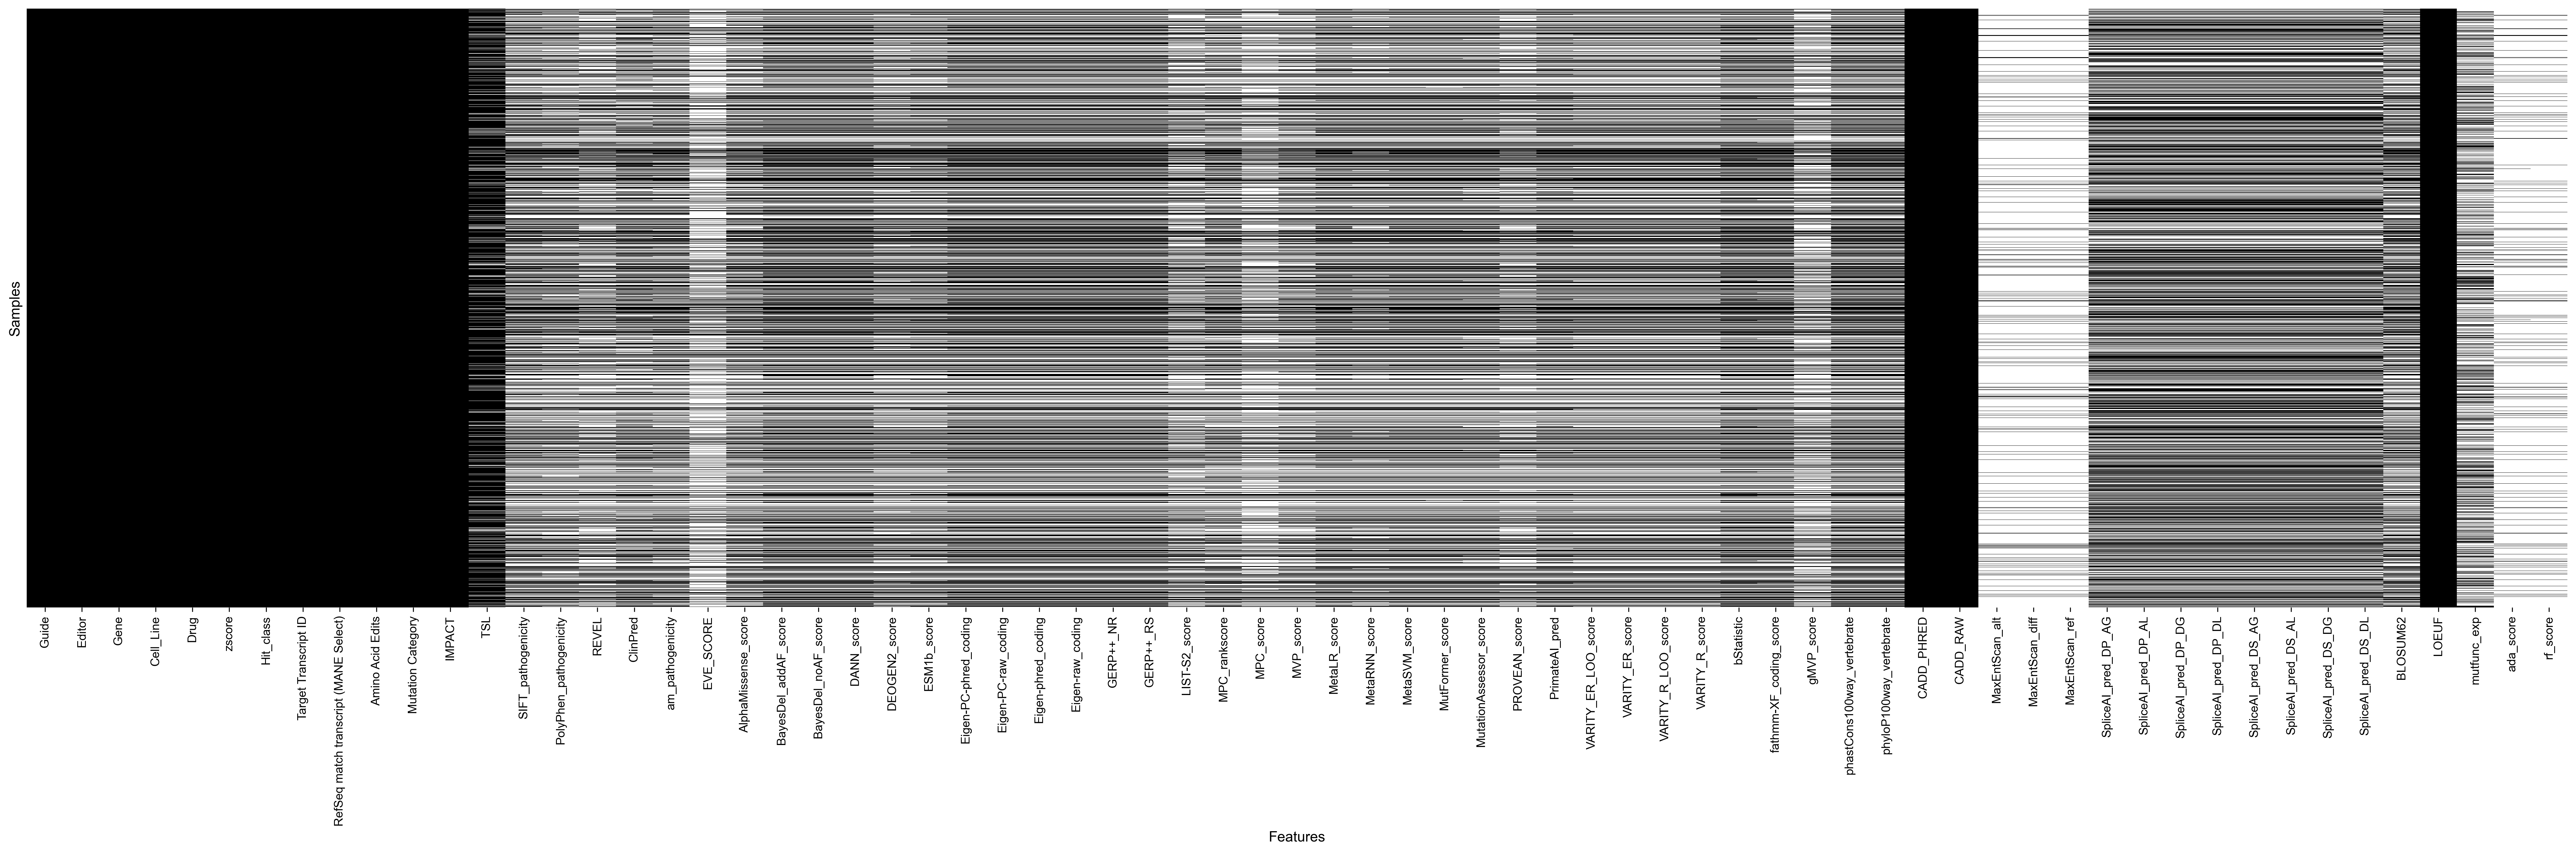

In [79]:
#Heatmap of missing values
plt.figure(figsize=(30, 10))

sns.heatmap(
    zscores_palsmid_vs_control_EG_annotated_processed.isnull(),
    cbar=False,
    cmap='binary_r'
)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Samples", fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.yticks([])  # Hide sample indices
plt.tight_layout()
plt.show()

# Encode Categorical Labels

In [257]:
#Work on the copy
zscores_plasmid_unambiguous_VEPannotated_encoded = zscores_plasmid_unambiguous_VEPannotated_processed.copy()

#IMPACT
impact_encoder = OrdinalEncoder(categories=[['MODIFIER', 'LOW', 'MODERATE', 'HIGH']])
zscores_plasmid_unambiguous_VEPannotated_encoded['IMPACT_enc'] = impact_encoder.fit_transform(zscores_plasmid_unambiguous_VEPannotated_encoded[['IMPACT']])


#Mutation Category
mutcat_encoder = OrdinalEncoder(categories=[['Intron', 'UTR', 'Silent', 'Missense', 'Nonsense', 'Splice-acceptor','Splice-donor']])
zscores_plasmid_unambiguous_VEPannotated_encoded['Mutation_Category_enc'] = mutcat_encoder.fit_transform(zscores_plasmid_unambiguous_VEPannotated_encoded[['Mutation Category']])


#PrimateAI_pred
primateAI_encoder = OrdinalEncoder(categories=[['D', 'T']], handle_unknown='use_encoded_value', unknown_value=np.nan)
zscores_plasmid_unambiguous_VEPannotated_encoded['PrimateAI_pred_enc'] = primateAI_encoder.fit_transform(zscores_plasmid_unambiguous_VEPannotated_encoded[['PrimateAI_pred']])


#Reorder the columns
cols = zscores_plasmid_unambiguous_VEPannotated_encoded.columns.tolist()
cols.insert(cols.index('PrimateAI_pred') + 1, cols.pop(cols.index('PrimateAI_pred_enc')))
cols.insert(cols.index('Mutation Category') + 1, cols.pop(cols.index('Mutation_Category_enc')))
cols.insert(cols.index('IMPACT') + 1, cols.pop(cols.index('IMPACT_enc')))

zscores_plasmid_unambiguous_VEPannotated_encoded = zscores_plasmid_unambiguous_VEPannotated_encoded[cols]

In [80]:
#for zscores_palsmid_vs_control_EG_annotated_processed
zscores_palsmid_vs_control_EG_annotated_encoded = zscores_palsmid_vs_control_EG_annotated_processed.copy()

#IMPACT
impact_encoder = OrdinalEncoder(categories=[['MODIFIER', 'LOW', 'MODERATE', 'HIGH']])
zscores_palsmid_vs_control_EG_annotated_encoded['IMPACT_enc'] = impact_encoder.fit_transform(zscores_palsmid_vs_control_EG_annotated_encoded[['IMPACT']])


#Mutation Category
mutcat_encoder = OrdinalEncoder(categories=[['Intron', 'UTR', 'Silent', 'Missense', 'Nonsense', 'Splice-acceptor','Splice-donor']])
zscores_palsmid_vs_control_EG_annotated_encoded['Mutation_Category_enc'] = mutcat_encoder.fit_transform(zscores_palsmid_vs_control_EG_annotated_encoded[['Mutation Category']])


#PrimateAI_pred
primateAI_encoder = OrdinalEncoder(categories=[['D', 'T']], handle_unknown='use_encoded_value', unknown_value=np.nan)
zscores_palsmid_vs_control_EG_annotated_encoded['PrimateAI_pred_enc'] = primateAI_encoder.fit_transform(zscores_palsmid_vs_control_EG_annotated_encoded[['PrimateAI_pred']])


#Reorder the columns
cols = zscores_palsmid_vs_control_EG_annotated_encoded.columns.tolist()
cols.insert(cols.index('PrimateAI_pred') + 1, cols.pop(cols.index('PrimateAI_pred_enc')))
cols.insert(cols.index('Mutation Category') + 1, cols.pop(cols.index('Mutation_Category_enc')))
cols.insert(cols.index('IMPACT') + 1, cols.pop(cols.index('IMPACT_enc')))

zscores_palsmid_vs_control_EG_annotated_encoded = zscores_palsmid_vs_control_EG_annotated_encoded[cols]

In [190]:
#for control
zscores_control_unambiguous_VEPannotated_encoded = zscores_control_unambiguous_VEPannotated_processed.copy()

#IMPACT
zscores_control_unambiguous_VEPannotated_encoded['IMPACT_enc'] = impact_encoder.fit_transform(zscores_control_unambiguous_VEPannotated_encoded[['IMPACT']])

#Mutation Category
zscores_control_unambiguous_VEPannotated_encoded['Mutation_Category_enc'] = mutcat_encoder.fit_transform(zscores_control_unambiguous_VEPannotated_encoded[['Mutation Category']])

#PrimateAI_pred
zscores_control_unambiguous_VEPannotated_encoded['PrimateAI_pred_enc'] = primateAI_encoder.fit_transform(zscores_control_unambiguous_VEPannotated_encoded[['PrimateAI_pred']])

#Reorder the columns
cols_control = zscores_control_unambiguous_VEPannotated_encoded.columns.tolist()
cols_control.insert(cols_control.index('PrimateAI_pred') + 1, cols_control.pop(cols_control.index('PrimateAI_pred_enc')))
cols_control.insert(cols_control.index('Mutation Category') + 1, cols_control.pop(cols_control.index('Mutation_Category_enc')))
cols_control.insert(cols_control.index('IMPACT') + 1, cols_control.pop(cols_control.index('IMPACT_enc')))

zscores_control_unambiguous_VEPannotated_encoded = zscores_control_unambiguous_VEPannotated_encoded[cols_control]

In [258]:
#Drop the original categorical columns
zscores_plasmid_unambiguous_VEPannotated_encoded = zscores_plasmid_unambiguous_VEPannotated_encoded.drop(columns=['IMPACT', 'Mutation Category', 'PrimateAI_pred'])

In [81]:
# for zscores_palsmid_vs_control_EG_annotated_encoded
zscores_palsmid_vs_control_EG_annotated_encoded = zscores_palsmid_vs_control_EG_annotated_encoded.drop(columns=['IMPACT', 'Mutation Category', 'PrimateAI_pred'])


In [191]:
#for control
zscores_control_unambiguous_VEPannotated_encoded = zscores_control_unambiguous_VEPannotated_encoded.drop(columns=['IMPACT', 'Mutation Category', 'PrimateAI_pred'])

In [82]:
zscores_palsmid_vs_control_EG_annotated_encoded.head()


,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,AlphaMissense_score,BayesDel_addAF_score,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,Eigen-phred_coding,Eigen-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaLR_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_ER_LOO_score,VARITY_ER_score,VARITY_R_LOO_score,VARITY_R_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,CADD_RAW,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,rf_score
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,DO,-0.126512,non-hit,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,0.0685,NaN,0.0685,-0.114447,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,4.111072,0.361058,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.0689,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.157308,0.157308,0.094767,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,2.813513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,DO,0.491844,non-hit,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,0.1149,NaN,0.1149,0.010688,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,2.801108,0.078205,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.1053,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.106259,0.106259,0.072730,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,3.741037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,DO,0.161287,non-hit,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,0.7209,NaN,NaN,0.125089,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.445983,0.549592,5.63,3.78,NaN,0.73854,NaN,NaN,0.7441,NaN,0.6434,0.529280,3.705,NaN,0.0,0.443503,0.443503,0.365695,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,4.475384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,DO,-0.429684,non-hit,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,0.879011,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,NaN
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,DO,0.122982,non-hit,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,NaN,0.1399,-0.139436,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,1.853913,-0.208103,4.31,2.43,0.397160,NaN,NaN,0.733174,0.3185,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,NaN,NaN,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,3.287154,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,NaN


In [92]:
#Check data types 
VEP_info_encoded = pd.DataFrame({
    'dtype': zscores_palsmid_vs_control_EG_annotated_encoded.dtypes,
    'non-null count': zscores_palsmid_vs_control_EG_annotated_encoded.notna().sum(),
    'missing (%)': zscores_palsmid_vs_control_EG_annotated_encoded.isna().mean() * 100,
    'n_unique': zscores_palsmid_vs_control_EG_annotated_encoded.nunique(),
    'example': zscores_palsmid_vs_control_EG_annotated_encoded.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(zscores_palsmid_vs_control_EG_annotated_encoded)} rows and {len(zscores_palsmid_vs_control_EG_annotated_encoded.columns)} columns')
VEP_info_encoded

28086 rows and 59 columns


,dtype,non-null count,missing (%),n_unique,example
Guide,object,28086,0.000000,14043,"[AAAAAACATCGTAGTAGCAG, AAAAAACTCAACAGCAGTGA, A..."
LOEUF,float64,28086,0.000000,30,"[0.305, 0.55, 0.319]"
IMPACT_enc,float64,28086,0.000000,4,"[2.0, 1.0, 3.0]"
CADD_PHRED,float64,28086,0.000000,3016,"[20.4, 23.4, 25.4]"
Amino Acid Edits,object,28086,0.000000,8729,"[His1109Tyr, Leu171Phe, Thr930Ile]"
RefSeq match transcript (MANE Select),object,28086,0.000000,30,"[NM_152756.5, NM_002524.5, NM_006219.3]"
Target Transcript ID,object,28086,0.000000,30,"[ENST00000357387.8, ENST00000369535.5, ENST000..."
Mutation_Category_enc,float64,28086,0.000000,7,"[3.0, 2.0, 5.0]"
zscore,float64,28086,0.000000,27465,"[-0.1265120188067817, 0.4918440305585236, 0.16..."
Drug,object,28086,0.000000,1,[DO]


# Correlation Analysis

In [3]:
#Check correlation only with loss of function mutations (negative z-scores)
zscores_palsmid_vs_control_EG_annotated_encoded = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv")
lof_df = zscores_palsmid_vs_control_EG_annotated_encoded[zscores_palsmid_vs_control_EG_annotated_encoded['Hit_class'] == 'negative'].copy()

In [7]:
lof_df['Hit_class'].value_counts()

Hit_class
negative    810
Name: count, dtype: int64

In [10]:
# Drop meta columns and create a training fetaures only dataset
training_features_df = lof_df.drop(columns=meta_cols, errors='ignore')

print(f"Shape of feature dataset: {training_features_df.shape}")

Shape of feature dataset: (810, 50)


In [11]:
#Check data types 
VEP_info_features = pd.DataFrame({
    'dtype': training_features_df.dtypes,
    'non-null count': training_features_df.notna().sum(),
    'missing (%)': training_features_df.isna().mean() * 100,
    'n_unique': training_features_df.nunique(),
    'example': training_features_df.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(training_features_df)} rows and {len(training_features_df.columns)} columns')
VEP_info_features

810 rows and 50 columns


,dtype,non-null count,missing (%),n_unique,example
zscore,float64,810,0.000000,807,"[-2.0541916007420387, -3.8517802753385673, -4...."
LOEUF,float64,810,0.000000,27,"[0.33, 0.268, 0.461]"
CADD_PHRED,float64,810,0.000000,168,"[31.0, 27.8, 25.8]"
Mutation_Category_enc,float64,810,0.000000,7,"[5.0, 3.0, 2.0]"
IMPACT_enc,float64,810,0.000000,4,"[3.0, 2.0, 1.0]"
phastCons100way_vertebrate,float64,607,25.061728,14,"[1.0, 0.994, 0.686]"
phyloP100way_vertebrate,float64,607,25.061728,221,"[7.248, 7.478, 9.883]"
GERP++_RS,float64,607,25.061728,145,"[5.51, 5.7, 5.8]"
BayesDel_noAF_score,float64,607,25.061728,253,"[0.376218, 0.00610525, 0.429531]"
DANN_score,float64,607,25.061728,347,"[0.9982529021052188, 0.999446573834932, 0.9993..."


In [12]:
# Compute correlation matrix
corr_matrix = training_features_df.corr()
corr_matrix

,zscore,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score
zscore,1.000000,-0.111317,-0.115237,0.062848,0.094664,-0.051526,-0.340447,-0.092575,-0.134573,-0.202627,-0.138520,-0.065383,-0.042285,0.232696,-0.041682,-0.043170,0.049871,0.025109,-0.037898,-0.040645,-0.029425,-0.169750,-0.152182,-0.158561,-0.124168,-0.089577,0.181645,0.119127,-0.147242,-0.015695,-0.007761,-0.226602,-0.055839,-0.006873,-0.122275,-0.054266,-0.000386,-0.087071,-0.074228,-0.023941,0.006389,0.060416,-0.109838,-0.086022,0.034748,0.054138,0.155431,0.009822,-0.059218,0.021410
Mutation_Category_enc,-0.111317,1.000000,0.907237,-0.004746,NaN,NaN,NaN,-0.285374,NaN,NaN,0.689586,0.076416,NaN,NaN,0.384342,0.296333,0.121212,-0.022710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.189087,-0.802784,NaN,0.055280,-0.116330,0.706472,-0.417114,0.617338,0.148887,-0.026640,0.040479,0.048332,-0.101751,0.451131,0.609251,0.053026,0.113674,NaN,-0.125801,0.084640,0.581700
IMPACT_enc,-0.115237,0.907237,1.000000,-0.017307,NaN,NaN,NaN,-0.285374,NaN,NaN,0.689586,0.076416,NaN,NaN,0.384342,0.296333,0.121212,-0.022710,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.189087,-0.802784,NaN,0.055280,-0.116330,0.875226,-0.282138,0.493454,0.200796,-0.000758,0.020554,0.016960,-0.116215,0.332874,0.454983,0.021101,0.041661,NaN,-0.160371,0.084640,0.479555
TSL,0.062848,-0.004746,-0.017307,1.000000,-0.041530,-0.050810,0.010179,0.084231,0.095359,-0.064249,-0.004586,0.032735,0.209115,0.182243,-0.127589,-0.063508,0.139274,0.079328,0.094771,0.152328,0.126399,0.061907,-0.007316,-0.076028,0.279914,-0.150743,0.090591,-0.154947,0.026732,0.275950,0.040319,0.066613,0.028786,-0.038303,-0.043555,0.081541,-0.068960,0.035903,-0.081214,-0.149415,-0.238373,0.103690,-0.018465,0.048575,-0.051790,0.037585,-0.108299,-0.243419,NaN,-0.086406
SIFT_pathogenicity,0.094664,NaN,NaN,-0.041530,1.000000,-0.293743,-0.334511,-0.443197,-0.377912,-0.342427,-0.312524,-0.623150,-0.235461,0.369383,-0.244198,-0.361882,0.017319,-0.097561,-0.210327,-0.290797,-0.264119,-0.251510,-0.381569,-0.259537,-0.254997,-0.293723,0.321218,0.142830,-0.306844,0.010664,-0.340886,-0.412124,-0.078176,-0.286137,-0.366499,0.539847,-0.354672,0.530997,0.067352,0.083802,0.068249,0.122726,-0.038684,-0.040667,0.464573,-0.001213,0.172861,0.103547,-0.088715,-0.999839
PolyPhen_pathogenicity,-0.051526,NaN,NaN,-0.050810,-0.293743,1.000000,0.395936,0.503888,0.601194,0.628706,0.473043,0.247425,0.363182,-0.501667,0.646992,0.675364,0.113398,0.207995,0.381250,0.535355,0.519188,0.144921,0.691343,0.517102,0.329602,0.373118,-0.526906,-0.167134,0.579908,0.141417,0.449324,0.575858,0.107335,0.377481,0.493355,0.321082,-0.587501,-0.136844,0.052735,0.047578,0.014774,-0.104478,0.066627,0.097956,-0.172080,-0.117440,-0.322013,-0.048212,0.287449,0.396669
REVEL,-0.340447,NaN,NaN,0.010179,-0.334511,0.395936,1.000000,0.530534,0.705933,0.702697,0.846997,0.239306,0.690939,-0.626054,0.641821,0.670246,0.288998,0.332011,0.421262,0.477965,0.545661,0.766719,0.811735,0.895820,0.591420,0.553331,-0.615224,-0.359780,0.681986,-0.059485,0.495818,0.748365,0.195880,0.345568,0.493877,0.239828,-0.459029,-0.143578,-0.001594,-0.076577,0.037386,-0.210450,0.178254,0.119553,-0.186899,0.080451,-0.301403,-0.046496,0.280874,0.655476
ClinPred,-0.092575,-0.285374,-0.285374,0.084231,-0.443197,0.503888,0.530534,1.000000,0.60

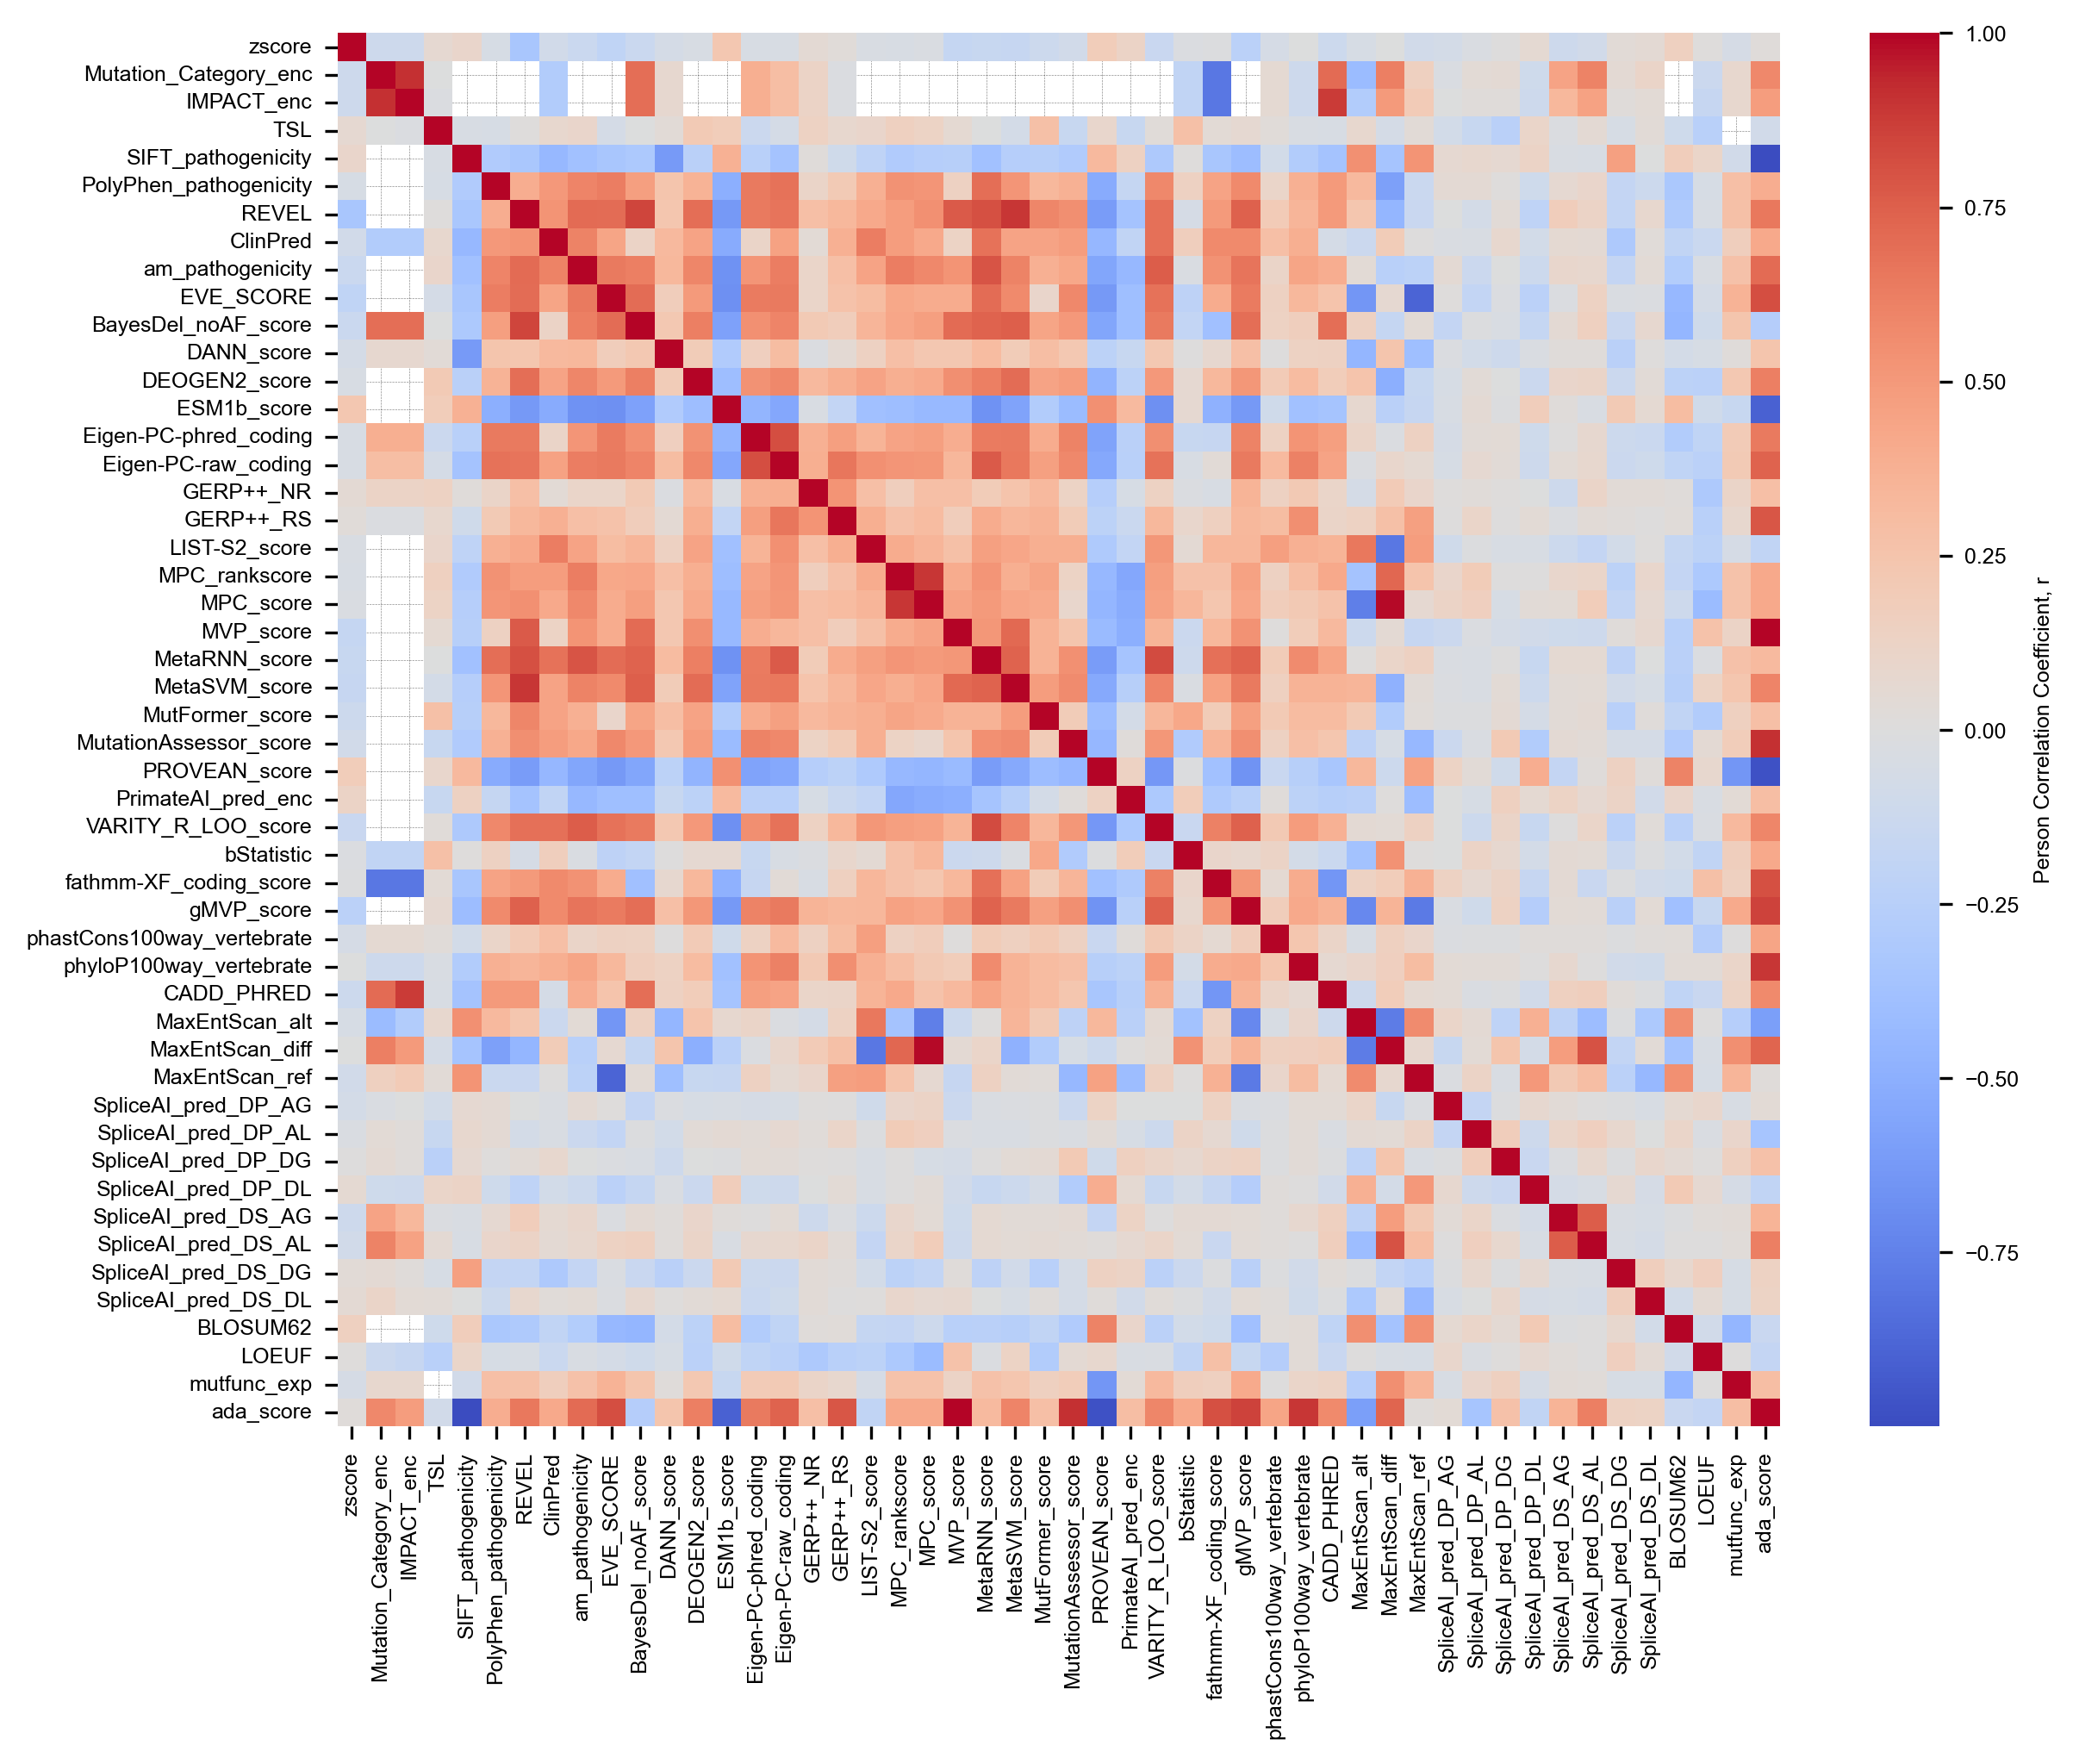

In [13]:
# Plot heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, cbar_kws={'label': 'Person Correlation Coefficient, r'})
plt.show()

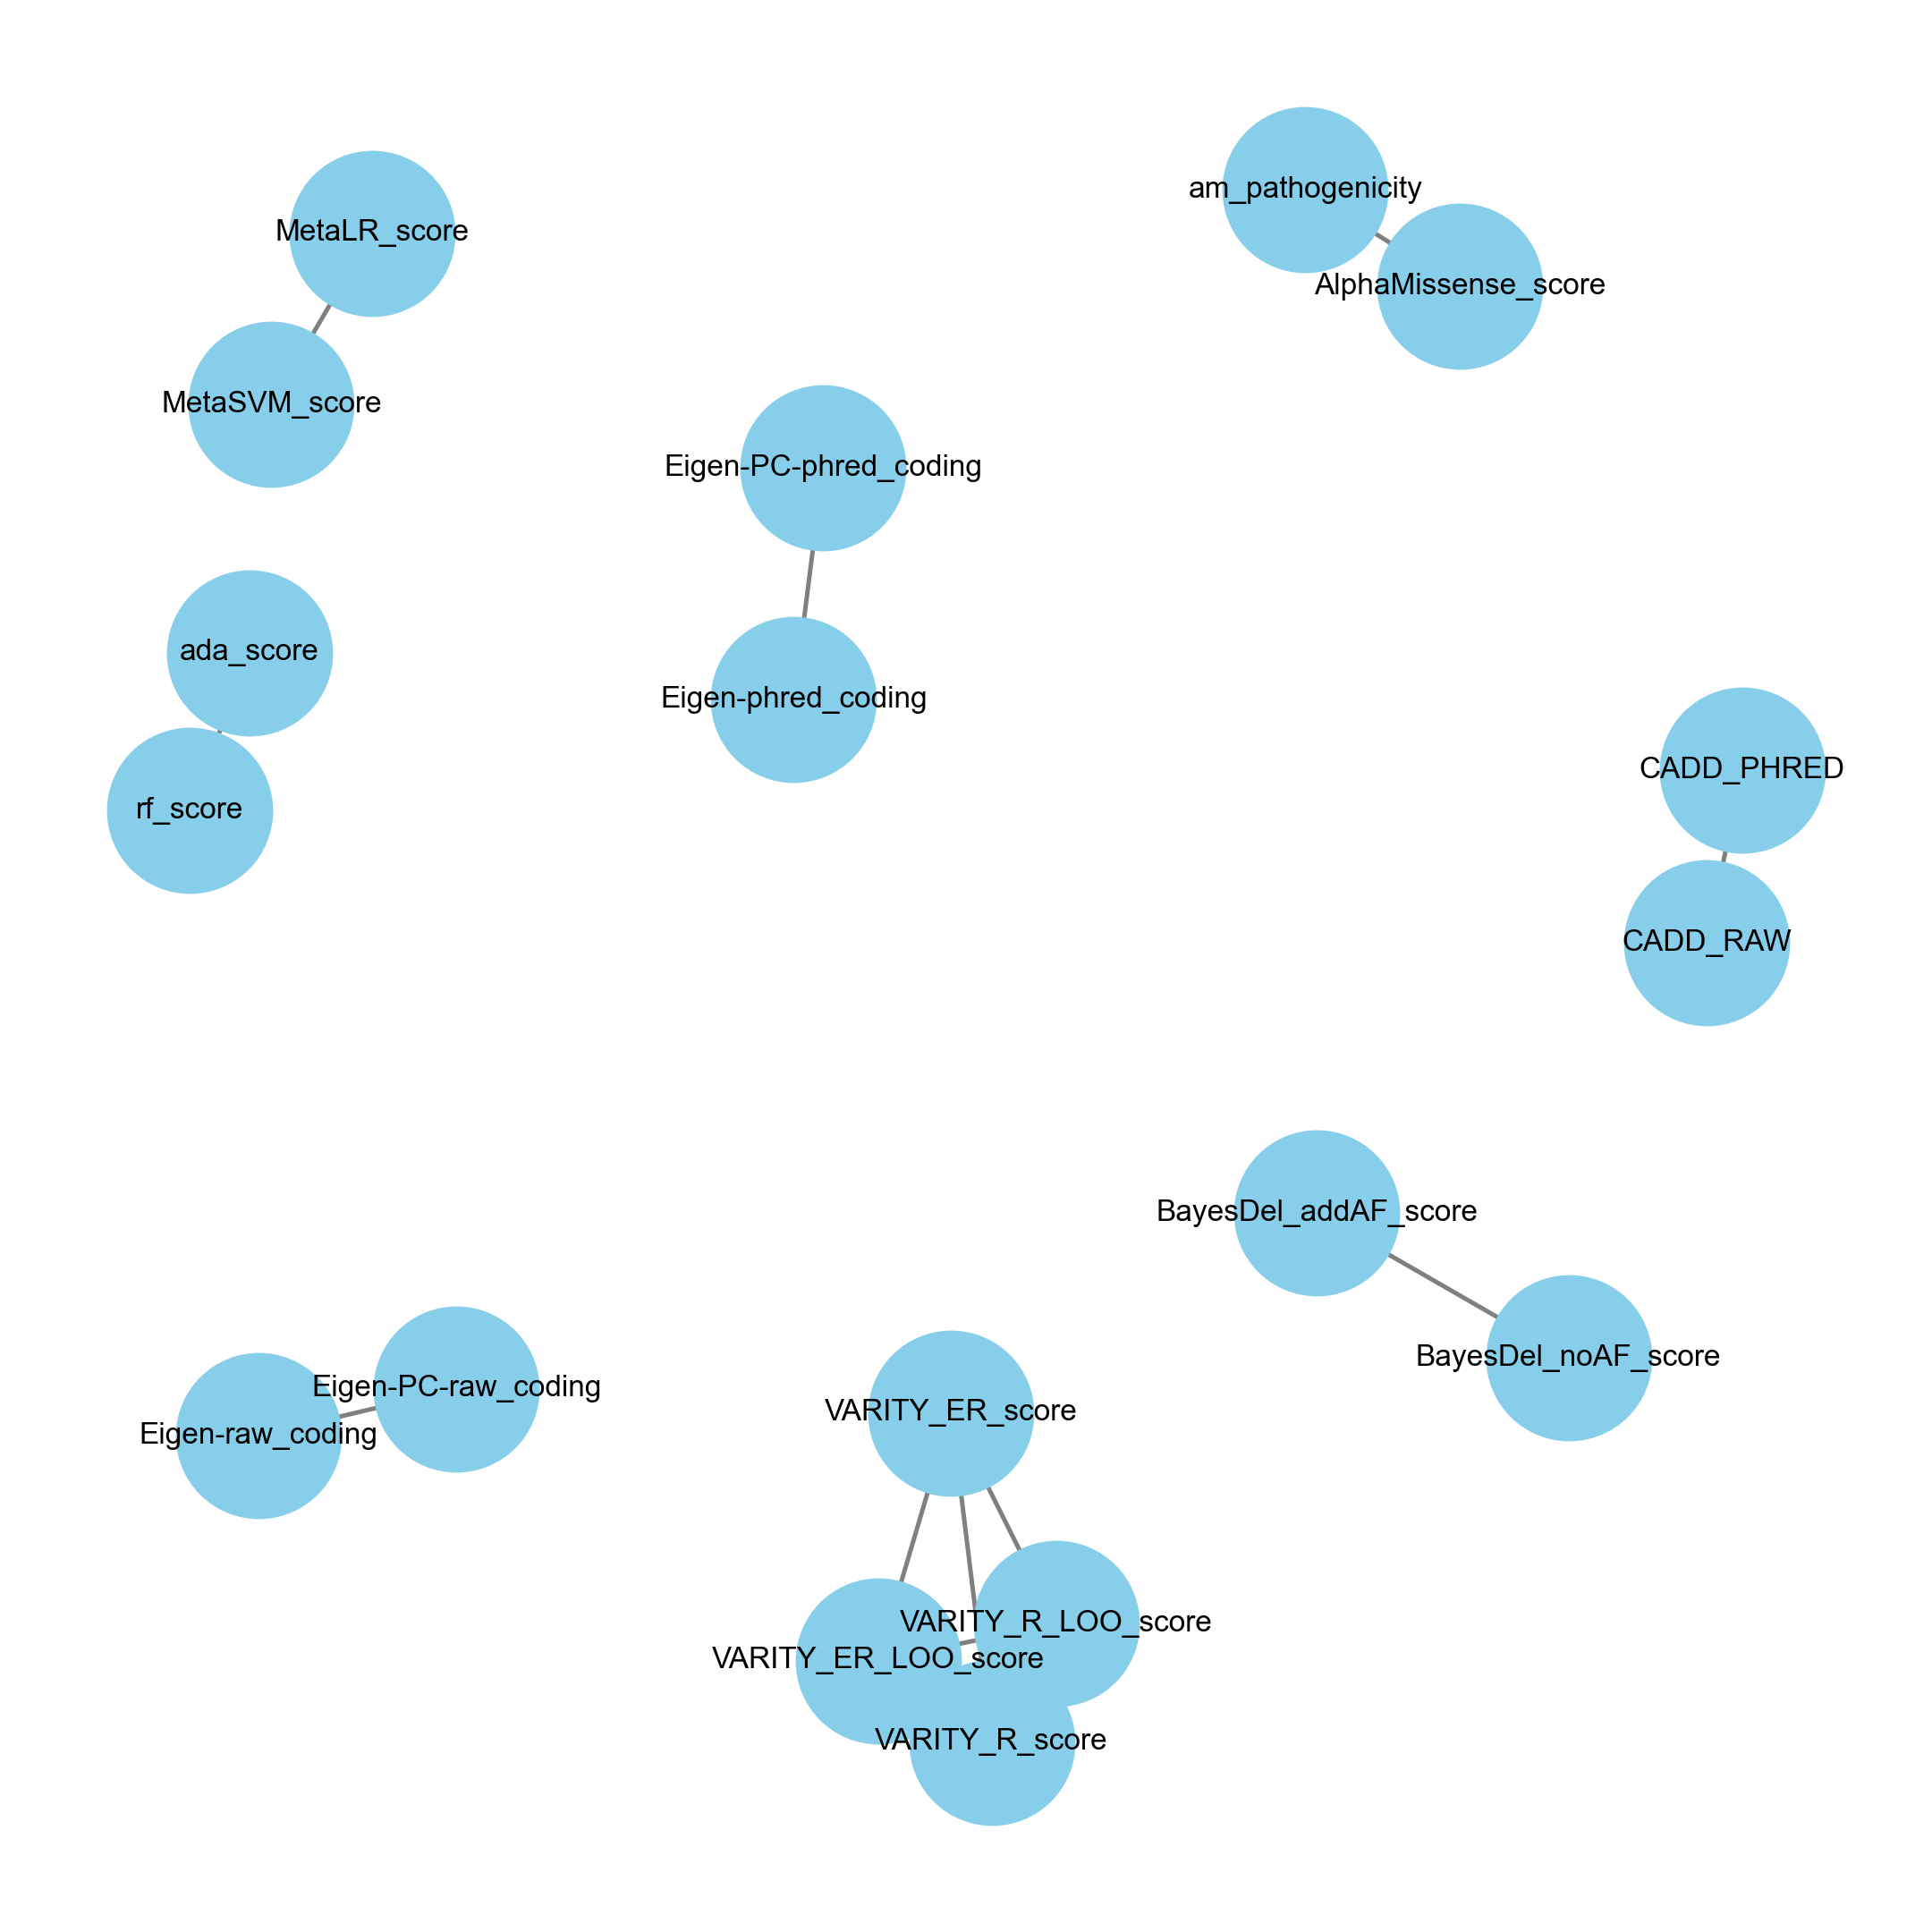

In [90]:
import networkx as nx

threshold = 0.95
G = nx.Graph()

# Add edges for highly correlated pairs
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > threshold:
            G.add_edge(col, row, weight=corr_matrix.loc[row, col])

plt.figure(figsize=(7,7))
pos = nx.spring_layout(G, k=1.1, iterations=100) 
nx.draw(
    G, pos,
    with_labels=True,
    node_size=1900,
    font_size=8,
    font_weight="normal",
    node_color="skyblue",
    edge_color="gray",
    width=1.2
)

#plt.title("Correlation Network Graph (>0.9)")
plt.show()

In [91]:
#AlphaMissense_score in the case of plasmid vs control for EG
columns_to_drop_corr = [
    'AlphaMissense_score', 
    'CADD_RAW',
    'BayesDel_addAF_score',
    'MetaLR_score',
    'VARITY_ER_score',
    'VARITY_ER_LOO_score',
    'VARITY_R_score',
    'Eigen-raw_coding',
    'Eigen-phred_coding',
    'rf_score'
]

#Drop the correlated (>0.95) columns
zscores_palsmid_vs_control_EG_annotated_encoded = (zscores_palsmid_vs_control_EG_annotated_encoded.drop(columns=columns_to_drop_corr))

print(f"Shape after dropping correlated columns: {zscores_palsmid_vs_control_EG_annotated_encoded.shape}")

Shape after dropping correlated columns: (28086, 59)


In [ ]:
#Drop the correlated (>0.95) columns for control
zscores_control_unambiguous_VEPannotated_encoded = (zscores_control_unambiguous_VEPannotated_encoded.drop(columns=columns_to_drop_corr))
print(f"Shape after dropping correlated columns for control: {zscores_control_unambiguous_VEPannotated_encoded.shape}")

In [264]:
zscores_plasmid_unambiguous_VEPannotated_encoded.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid.csv", index=False)

In [198]:
zscores_control_unambiguous_VEPannotated_encoded.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-control.csv", index=False)

In [93]:
zscores_palsmid_vs_control_EG_annotated_encoded.to_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv", index=False)

# z-scores vs position plots colored by VEP scores

In [ ]:
zscores_plasmid_unambiguous_VEPannotated_hits = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated_hits.csv")

In [ ]:
zscores_plasmid_unambiguous_VEPannotated_hits.head(5)

In [173]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_gene_conditions(
    df: pd.DataFrame,
    gene: str,
    vep_col: str,
    colorbar_label: str = None,
    condition_cols=("Cell_Line", "Drug"),
    point_size: int = 18,
    cmap: str = "viridis",
    max_cols: int = 3,
):
    # Filter by gene
    data = df[df["Gene"] == gene].copy()
    if data.empty:
        print(f"No data for gene {gene}")
        return

    # Build a readable condition string and (optionally) append Source
    if "Source" in data.columns:
        base = data.loc[:, condition_cols].astype(str).agg(" | ".join, axis=1)
        src  = data["Source"].fillna("")
        data["Condition"] = np.where(src.eq(""), base, base + " | " + src.astype(str))
    else:
        data["Condition"] = data.loc[:, condition_cols].astype(str).agg(" | ".join, axis=1)

    conditions = data["Condition"].unique()
    n = len(conditions)

    # Grid geometry + figure size that scales with n
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)
    fig_w = 4.5 * ncols
    fig_h = 3.8 * nrows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=True,   # <-- key to prevent overlap
        squeeze=False
    )

    # Color scaling shared across all subplots
    vmin = data[vep_col].min()
    vmax = data[vep_col].max()

    # Plot each condition
    last_sc = None
    for ax, cond in zip(axes.ravel(), conditions):
        sub = data[data["Condition"] == cond]
        last_sc = ax.scatter(
            sub["Protein_position"],
            sub["zscore"],
            c=sub[vep_col],
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=0.8,
            edgecolors="none"
        )
        ax.set_title(cond, fontsize=10)
        ax.set_xlabel("Protein position", fontsize=9)
        ax.set_ylabel("Z-score", fontsize=9)
        ax.tick_params(labelsize=8)

    # Hide any unused axes
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    # One shared colorbar to the right
    if last_sc is not None:
        cbar = fig.colorbar(
            last_sc,
            ax=axes.ravel().tolist(),
            location="right",
            shrink=0.5,   # slightly shorter than full height
            pad=0.02,
            aspect=30
        )
        cbar.set_label(colorbar_label if colorbar_label else vep_col, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    plt.show()

In [ ]:
plot_gene_conditions(
    df=zscores_plasmid_unambiguous_VEPannotated_hits,
    gene="PIK3CA",
    vep_col="AlphaMissense_score",
    colorbar_label="AlphaMissense score",
    condition_cols=["Cell_Line", "Drug"],
)

In [175]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_gene_conditions(
    df: pd.DataFrame,
    gene: str,
    vep_col: str,
    colorbar_label: str = None,
    condition_cols=("Cell_Line", "Drug"),
    point_size: int = 18,
    cmap: str = "viridis",
    max_cols: int = 3,
):
    # Filter by gene
    data = df[df["Gene"] == gene].copy()
    if data.empty:
        print(f"No data for gene {gene}")
        return

    # Build a readable condition string:
    #   Cell_Line + Drug  (and append " | Source" when Source exists)
    plus_sep = " + "
    base = data.loc[:, condition_cols].astype(str).agg(plus_sep.join, axis=1)
    if "Source" in data.columns:
        src = data["Source"].fillna("")
        data["Condition"] = np.where(src.eq(""), base, base + " | " + src.astype(str))
    else:
        data["Condition"] = base

    conditions = data["Condition"].unique()
    n = len(conditions)

    # Grid geometry + figure size that scales with n
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)
    fig_w = 4.5 * ncols
    fig_h = 3.8 * nrows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=False,   # we'll control spacing manually
        squeeze=False
    )
    # Add extra vertical space between rows (and a bit of horizontal space)
    fig.subplots_adjust(hspace=0.6, wspace=0.25)

    # Color scaling shared across all subplots
    vmin = data[vep_col].min()
    vmax = data[vep_col].max()

    # Plot each condition
    last_sc = None
    for ax, cond in zip(axes.ravel(), conditions):
        sub = data[data["Condition"] == cond]
        last_sc = ax.scatter(
            sub["Protein_position"],
            sub["zscore"],
            c=sub[vep_col],
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=0.8,
            edgecolors="none"
        )
        ax.set_title(cond, fontsize=10)
        ax.set_xlabel("Protein position", fontsize=9)
        ax.set_ylabel("Z-score", fontsize=9)
        ax.tick_params(labelsize=8)

    # Hide any unused axes
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    # One shared colorbar to the right
    if last_sc is not None:
        cbar = fig.colorbar(
            last_sc,
            ax=axes.ravel().tolist(),
            location="right",
            shrink=0.5,
            pad=0.02,
            aspect=30  # adjust if you want it thinner/thicker
        )
        cbar.set_label(colorbar_label if colorbar_label else vep_col, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    plt.show()

In [177]:
def plot_gene_conditions(
    df: pd.DataFrame,
    gene: str,
    vep_col: str,
    colorbar_label: str = None,
    condition_cols=("Cell_Line", "Drug"),
    point_size: int = 18,
    cmap: str = "viridis",
    max_cols: int = 3,
):
    # Filter by gene
    data = df[df["Gene"] == gene].copy()
    if data.empty:
        print(f"No data for gene {gene}")
        return

    # Build a readable condition string
    plus_sep = " + "
    base = data.loc[:, condition_cols].astype(str).agg(plus_sep.join, axis=1)
    if "Source" in data.columns:
        src = data["Source"].fillna("")
        data["Condition"] = np.where(src.eq(""), base, base + " | " + src.astype(str))
    else:
        data["Condition"] = base

    conditions = data["Condition"].unique()
    n = len(conditions)

    # Grid geometry + figure size that scales with n
    ncols = min(max_cols, n)
    nrows = math.ceil(n / ncols)
    fig_w = 4.5 * ncols
    fig_h = 3.8 * nrows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(fig_w, fig_h),
        constrained_layout=False,
        squeeze=False
    )
    fig.subplots_adjust(hspace=0.6, wspace=0.25)

    # Color scaling shared across all subplots
    vmin = data[vep_col].min()
    vmax = data[vep_col].max()

    # Global symmetric y-axis across all subplots
    y_absmax = max(abs(data["zscore"].min()), abs(data["zscore"].max()))
    y_min, y_max = -y_absmax, y_absmax

    # Plot each condition
    last_sc = None
    for ax, cond in zip(axes.ravel(), conditions):
        sub = data[data["Condition"] == cond]
        last_sc = ax.scatter(
            sub["Protein_position"],
            sub["zscore"],
            c=sub[vep_col],
            s=point_size,
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            alpha=0.8,
            edgecolors="none"
        )
        ax.set_title(cond, fontsize=10)
        ax.set_xlabel("Protein position", fontsize=9)
        ax.set_ylabel("Z-score", fontsize=9)
        ax.tick_params(labelsize=8)

        # Force symmetric y-limits centered at 0
        ax.set_ylim(y_min, y_max)
        ax.axhline(0, color="gray", lw=0.8, linestyle="--")  # optional zero reference line

    # Hide unused axes
    for ax in axes.ravel()[n:]:
        ax.set_visible(False)

    # Shared colorbar
    if last_sc is not None:
        cbar = fig.colorbar(
            last_sc,
            ax=axes.ravel().tolist(),
            location="right",
            shrink=0.5,
            pad=0.02,
            aspect=25
        )
        cbar.set_label(colorbar_label if colorbar_label else vep_col, fontsize=10)
        cbar.ax.tick_params(labelsize=8)

    plt.show()